Notebook for processing data on Detection Efficiency prompted from the Sub-WP4-meeting between Sander and Sara on 28.05.2026

## Wiki

Simulations:
- 1\): 1e8 proton simulation with NOVO51 [1.05e6 x 70 sims]
- 2\): Na-22 source simulation [256 975]

For both simulations 3 additional copies of the detector were symmetrically positioned around the PMMA phantom (detection data is quadroupled)

For 2\) the PMMA phantom material was changed to AIR in order to "remove" it

Outputs:
- 40\): Scores PGs produced in the PMMA phantom 
- 41\): Scores photons escaping the PMMA phantom
- 42\): Scores photons entering any scintillator bar
- 80\): Interactions in any scintillator bar (the usual detection output)

#### 40\) PGs_produced_pmma
Formatting: .txt-file  
Values: NCASE ; TKI(IP) ; XSCO ; MREG  
Meaning: Primary ID; Kinetic energy ; X-coordinate (towards detector) ; Geometry region

#### 41\) gammas_escape_pmma
Formatting: .txt-file  
Values: NCASE ; LLOUSE ; ETRACK - AM(JTRACK) ; ZSCO  
Meaning: Primary ID ; "Directness" of photon ; Kinetic energy ; Z-coordinate (along PMMA-phantom)

#### 42\) gammas_enter_scints
Formatting: .txt-file  
Values: NCASE ; LLOUSE ; NEWREG ; ETRACK-AM(JTRACK) ; ZSCO  
Meaning: Primary ID ; "Directness" of photon ; Scintillator bar ID (1 -12) ; Kinetic energy ; Z-coordinate (along PMMA-phantom)

#### 80\) scintillator_interactions
Formatting: .txt-file  
Documentation of this is too long: Find explaination on the NOVO-cloud:   
\Simulations\FLUKA simulations for 2025-12_OncoRay\Documentation_FLUKA_OncoRay_sims.pptx


Plan for code:

Step 1:
- 1) Write output reader script for 40\) : OK
- 2) Write output reader script for 41\) : OK
- 3) Write output reader script for 42\) : OK

For steps 1) - 3) use the same function, but alter it slightly

Step 2:  
- 4) Write code to estimate how many photons escape PMMA per proton (ability to choose energies! Use numpy masks): OK
- 5) Write code to investigate gamma specter for the photons escaping PMMA (LLOUSE=0 and 1): OK
- 6) Write code to investigate escape depth (ZSCO): OK

Step 3:
- 7) Write code to estimate how many photons enter scintillator bar X (1 - 12 or all) (ability to choose energies! Use numpy masks): OK
- 8) Write code to investiagte gamma specter for these photons (corresponding bar X): OK

Step 4:  
- 9) Using pre-excisting code to estimate the number of gamma hits (=gammas detected): OK
- 10) Estimate how many gammas are detected per gamma entering the scintillator (=efficiency) (ability to choose energies! Use numpy masks): OK for NOVO51, ...
- 11) Investiagte gamma specter for Na-22: OK

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import time

from mgdraw_output_reader_NOVO_v04 import DetectionDataStorage  # Used for scintillator_interactions.txt


#### 1) Output reader script for 40\): PGs produced

In [2]:
def collect_txt_data_40(file_adress, primaries_per_spawn=1.2e6, spawn_number=1, FLUKA_to_meas_coords=False) -> str:
    # Function that will collect all data from a usdraw txt output file from mgdraw_v08_OncoRay_model_prods.f 
    # Optional input of the number primaries set in the FLUKA input. This is to ensure unique NCASE identifiers per proton, which might be the same across different spawns

    file_adress = file_adress.replace("\\", "/")

    import time
    print("Collecting data: ", end="")
    time_stamp = time.time()

    file = open(file_adress, "r")

    n = 0   # Line counter

    # Structure of detector output file, as of 06.08.2025
    ncase = [] # NCASE values: What primary proton created the secondaries we are investigating?
    energy = []  # TKi(IP) values: What was the kinetic energy produced PG? [GeV -> MeV]
    crash_x = [] # XSCO values: What was the X-coordinate of the production?   [cm]
    region = [] # MREG values: What was the region in which the production occured?
    
    # Looping over all lines in the file
    for line in file:
        if "Spawn number:" in line:
            spawn_number = int(line.split(":")[1].strip().split(" ")[0]) # Spawn number in the FLUKA run. Used for altering NCASE values 
            continue    # Spawn number lines should be skipped, they don't contain other information than spawn number

        # If "***********" is in a line, it means that not enough space has been allocated to a feature value.
        # This has so far only happened for particle age for neutrons. I choose to skip these entries.
        if "***********" in line:
            line = line.replace("*", "0")
    
        line = " ".join(line.split()) # Remove all spaces, while leaving one space between each value. Spaces in output file might not be universal
        n += 1  # Increment line counter

        # Collecting all data from the output.txt file
        ncase.append(int(line.split(" ")[0]) + (spawn_number - 1) * primaries_per_spawn) # Avoiding equal NCASEs in two different spawns. Example: NCASE 303 in spawn 4 for 2000 primaries is now NCASE 6303 [303 (4-1)*2000 = 6303]
        energy.append(int(line.split(" ")[1]))

        if FLUKA_to_meas_coords==True:
            crash_x.append(float(line.split(" ")[2]) - 54.2)    # -54.2 cm
        else:
            crash_x.append(float(line.split(" ")[2]))    
        region.append(int(line.split(" ")[3]))                   

    print(f"\rCollecting data: complete. {n} lines read. Time used: {round(time.time() - time_stamp, 3)} s", flush=True)
    return [ncase, energy, crash_x, region]

#### 2) Output reader script for 41\): Gammas leaving the PMMA phantom

In [3]:
def collect_txt_data_41(file_adress, primaries_per_spawn=1.2e6, spawn_number=1, FLUKA_to_meas_coords=False) -> str:
    # Function that will collect all data from a usdraw txt output file from mgdraw_v08_OncoRay_model_prods.f 
    # Optional input of the number primaries set in the FLUKA input. This is to ensure unique NCASE identifiers per proton, which might be the same across different spawns

    file_adress = file_adress.replace("\\", "/")

    import time
    print("Collecting data: ", end="")
    time_stamp = time.time()

    file = open(file_adress, "r")

    n = 0   # Line counter

    # Structure of detector output file, as of 06.08.2025
    ncase = [] # NCASE values: What primary proton created the secondaries we are investigating?
    directness_flag = [] # LLOUSE values: Does the interaction stem directly from target FN/PG-production?
    energy_in = []  # ETRACK-AM(JTRACK) values: What was the kinetic energy of the incoming particle? [GeV -> MeV]
    crash_z = [] # YSCO values: What was the X-coordinate of the interaction?   [cm]
    
    # Looping over all lines in the file
    for line in file:
        if "Spawn number:" in line:
            spawn_number = int(line.split(":")[1].strip().split(" ")[0]) # Spawn number in the FLUKA run. Used for altering NCASE values 
            continue    # Spawn number lines should be skipped, they don't contain other information than spawn number

        # If "***********" is in a line, it means that not enough space has been allocated to a feature value.
        # This has so far only happened for particle age for neutrons. I choose to skip these entries.
        if "***********" in line:
            line = line.replace("*", "0")
    
        line = " ".join(line.split()) # Remove all spaces, while leaving one space between each value. Spaces in output file might not be universal
        n += 1  # Increment line counter

        # Collecting all data from the output.txt file
        ncase.append(int(line.split(" ")[0]) + (spawn_number - 1) * primaries_per_spawn) # Avoiding equal NCASEs in two different spawns. Example: NCASE 303 in spawn 4 for 2000 primaries is now NCASE 6303 [303 (4-1)*2000 = 6303]
        directness_flag.append(int(line.split(" ")[1]))
        energy_in.append(round(float(line.split(" ")[2]) * 1000, 5))  # Multiplied by 1000 for get MeV from Gev

        if FLUKA_to_meas_coords==True:
            crash_z.append(float(line.split(" ")[3]) - 20)    # 20 cm from center PMMA phantom to PMMA phantom entrance
        else:
            crash_z.append(float(line.split(" ")[3]))                       

    print(f"\rCollecting data: complete. {n} lines read. Time used: {round(time.time() - time_stamp, 3)} s", flush=True)
    return [ncase, directness_flag, energy_in, crash_z]

#### 3) Output reader script for 42\): Gammas entering the PMMA phantom

In [4]:
def collect_txt_data_42(file_adress, primaries_per_spawn=1.2e6, spawn_number=1, FLUKA_to_meas_coords=False) -> str:
    # Function that will collect all data from a usdraw txt output file from mgdraw_v08_OncoRay_model_prods.f 
    # Optional input of the number primaries set in the FLUKA input. This is to ensure unique NCASE identifiers per proton, which might be the same across different spawns

    file_adress = file_adress.replace("\\", "/")

    import time
    print("Collecting data: ", end="")
    time_stamp = time.time()

    file = open(file_adress, "r")

    n = 0   # Line counter

    # Structure of detector output file, as of 06.08.2025
    ncase = [] # NCASE values: What primary proton created the secondaries we are investigating?
    directness_flag = [] # LLOUSE values: Does the interaction stem directly from target FN/PG-production?
    region = [] # NEWREG values: Into what scintillator is the particle entering?
    energy_in = []  # ETRACK-AM(JTRACK) values: What was the kinetic energy of the incoming particle? [GeV -> MeV]
    crash_z = [] # YSCO values: What was the X-coordinate of the interaction?   [cm]
    
    # Looping over all lines in the file
    for line in file:
        if "Spawn number:" in line:
            spawn_number = int(line.split(":")[1].strip().split(" ")[0]) # Spawn number in the FLUKA run. Used for altering NCASE values 
            continue    # Spawn number lines should be skipped, they don't contain other information than spawn number

        # If "***********" is in a line, it means that not enough space has been allocated to a feature value.
        # This has so far only happened for particle age for neutrons. I choose to skip these entries.
        if "***********" in line:
            line = line.replace("*", "0")
    
        line = " ".join(line.split()) # Remove all spaces, while leaving one space between each value. Spaces in output file might not be universal
        n += 1  # Increment line counter

        # Collecting all data from the output.txt file
        ncase.append(int(line.split(" ")[0]) + (spawn_number - 1) * primaries_per_spawn) # Avoiding equal NCASEs in two different spawns. Example: NCASE 303 in spawn 4 for 2000 primaries is now NCASE 6303 [303 (4-1)*2000 = 6303]
        directness_flag.append(int(line.split(" ")[1]))
        region.append(int(line.split(" ")[2]))
        energy_in.append(round(float(line.split(" ")[3]) * 1000, 5))  # Multiplied by 1000 for get MeV from Gev

        if FLUKA_to_meas_coords==True:
            crash_z.append(float(line.split(" ")[4]) - 20)    # 20 cm from center PMMA phantom to PMMA phantom entrance
        else:
            crash_z.append(float(line.split(" ")[4]))                       

    print(f"\rCollecting data: complete. {n} lines read. Time used: {round(time.time() - time_stamp, 3)} s", flush=True)
    return [ncase, directness_flag, region, energy_in, crash_z]

### Loading 41-data for NOVO51

In [5]:
# Loading data

NOVO51_41_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\Testing\Detector_efficiency\gammas_escape_pmma"
prim_per_spawn = 1.5e6  # x 70 spawns = 1.05e8 primaries in total
NOVO51_41_data = []

NOVO51_41_folder = os.listdir(NOVO51_41_PATH)
n_files = len(os.listdir(NOVO51_41_PATH))

n = 0   # Line counter
m = 0   # File counter

time_stamp = time.time()

print(f"Reading {n_files} gammas_escape_pmma.txt-files")

for filename in NOVO51_41_folder:
    
    m += 1

    # Skip any other files
    if "gammas_escape_pmma.txt" not in filename:
        break

    data_entry = collect_txt_data_41(NOVO51_41_PATH + "\\" + filename, primaries_per_spawn=prim_per_spawn , spawn_number=m, FLUKA_to_meas_coords=True) # Shape [eg. (3000, 1), ..., (3000, 1)]
    NOVO51_41_data.append(data_entry)

NOVO51_41_data = np.transpose(np.concatenate(NOVO51_41_data, axis=1))

Reading 70 gammas_escape_pmma.txt-files


#### 4) How many photons escape the PMMA phantom per proton?

In [6]:
# Doing stuff with the data
NOVO51_41_NCASEs = NOVO51_41_data[:, 0]
NOVO51_41_LLOUSEs = NOVO51_41_data[:, 1]
NOVO51_41_energies = NOVO51_41_data[:, 2]
NOVO51_41_XSCO = NOVO51_41_data[:, 3]

NOVO51_41_prod_rate = len(NOVO51_41_energies) / (70 * prim_per_spawn)

NOVO51_41_direct_mask = NOVO51_41_LLOUSEs==1
NOVO51_41_energies_direct = NOVO51_41_energies[NOVO51_41_direct_mask]

print(f"Total number of photons escaping the PMMA phantom: {len(NOVO51_41_energies)}, directly: {round(100 * (sum(NOVO51_41_LLOUSEs) / len(NOVO51_41_LLOUSEs)), 1)}%")
print(f"Ratio of escape versus production: {round(100 * NOVO51_41_prod_rate, 2)}%")

Total number of photons escaping the PMMA phantom: 13452913, directly: 55.0%
Ratio of escape versus production: 12.81%


#### 5) Gamma specter (direct vs not)

Text(0.5, 1.0, 'Gammas escaping PMMA phantom \nBin width: 0.05 MeV, bins: 400')

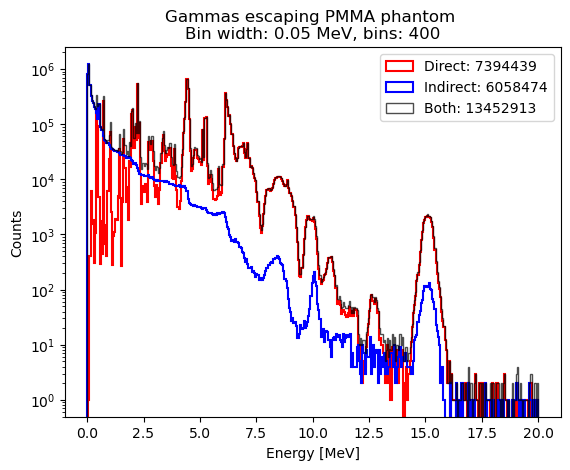

In [7]:
bin_width = 0.05 # MeV
min_energy = 0 # MeV
max_energy = 20   # MeV
bins = np.arange(min_energy, max_energy + bin_width, bin_width)

direct_mask = NOVO51_41_LLOUSEs==1

NOVO51_41_direct_energies = NOVO51_41_energies[direct_mask]
NOVO51_41_indirect_energies = NOVO51_41_energies[~direct_mask]

plt.hist(NOVO51_41_direct_energies, bins=bins, label=f"Direct: {len(NOVO51_41_direct_energies)}", color="red", histtype="step", lw=1.5)
plt.hist(NOVO51_41_indirect_energies, bins=bins, label=f"Indirect: {len(NOVO51_41_indirect_energies)}", color="blue", histtype="step", lw=1.5)
plt.hist(NOVO51_41_energies, bins=bins, label=f"Both: {len(NOVO51_41_energies)}", color="black", histtype="step", alpha=0.7)

plt.xlabel("Energy [MeV]")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.title(f"Gammas escaping PMMA phantom \nBin width: {bin_width} MeV, bins: {len(bins) - 1}")


#### 6) PMMA phantom escape depth

Text(0.5, 1.0, 'Gammas escaping per proton: 12.81% \n Bin width: 0.1 cm, bins: 400')

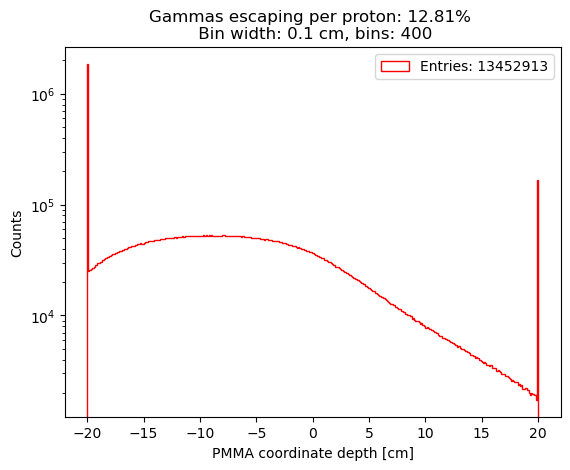

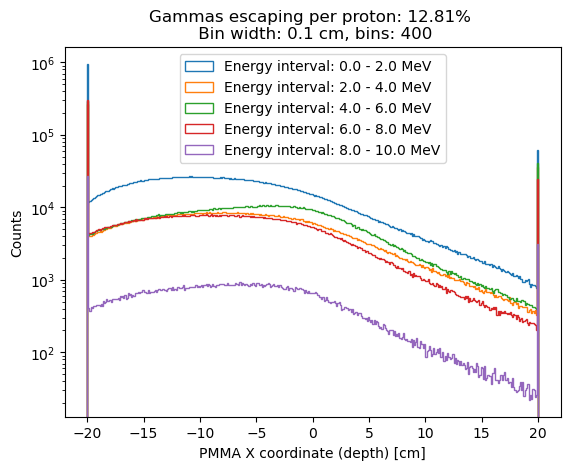

In [8]:
bin_width = 0.1 # cm
PMMA_start = -20 # cm
PMMA_end = 20   # cm
bins = np.arange(PMMA_start, PMMA_end + bin_width, bin_width)

plt.hist(NOVO51_41_XSCO, bins=bins, label=f"Entries: {len(NOVO51_41_XSCO)}", color="red", histtype="step")
plt.xlabel("PMMA coordinate depth [cm]")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.title(f"Gammas escaping per proton: {round(100 * NOVO51_41_prod_rate, 2)}% \n Bin width: {bin_width} cm, bins: {len(bins) - 1}")

# Differential escape stuff
plt.figure()
escape_energies = [1.0, 3.0, 5.0, 7.0, 9.0]

for escape_energy in escape_energies:
    escape_mask = (NOVO51_41_energies > escape_energy - 1.0) & (NOVO51_41_energies <= escape_energy + 1.0)
    escape_at_energy_XSCO = NOVO51_41_XSCO[escape_mask]

    plt.hist(escape_at_energy_XSCO, bins=bins, label=f"Energy interval: {escape_energy - 1.0} - {escape_energy + 1.0} MeV", histtype="step")
plt.xlabel("PMMA X coordinate (depth) [cm]")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.title(f"Gammas escaping per proton: {round(100 * NOVO51_41_prod_rate, 2)}% \n Bin width: {bin_width} cm, bins: {len(bins) - 1}")


### Loading 42-data for NOVO51

In [9]:
# Loading data

NOVO51_42_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\Testing\Detector_efficiency\gammas_enter_scints"
prim_per_spawn = 1.5e6  # x 70 spawns = 1.05e8 primaries in total
NOVO51_42_data = []

NOVO51_42_folder = os.listdir(NOVO51_42_PATH)
n_files = len(os.listdir(NOVO51_42_PATH))

n = 0   # Line counter
m = 0   # File counter

time_stamp = time.time()

print(f"Reading {n_files} gammas_enter_scints.txt-files")

for filename in NOVO51_42_folder:
    
    m += 1

    # Skip any other files
    if "gammas_enter_scints.txt" not in filename:
        break

    data_entry = collect_txt_data_42(NOVO51_42_PATH + "\\" + filename, primaries_per_spawn=prim_per_spawn , spawn_number=m, FLUKA_to_meas_coords=True) # Shape [eg. (3000, 1), ..., (3000, 1)]
    NOVO51_42_data.append(data_entry)

NOVO51_42_data = np.transpose(np.concatenate(NOVO51_42_data, axis=1))

Reading 70 gammas_enter_scints.txt-files


#### 7) Gammas entering scintillator bars

In [10]:
NOVO51_42_NCASEs = NOVO51_42_data[:, 0]
NOVO51_42_LLOUSEs = NOVO51_42_data[:, 1]
NOVO51_42_MREGs = NOVO51_42_data[:, 2]
NOVO51_42_energies = NOVO51_42_data[:, 3]
NOVO51_42_ZSCO = NOVO51_42_data[:, 4]

total_gammas_enter_scints = len(NOVO51_42_MREGs)
first_bar_mask = NOVO51_42_MREGs==1 # Region 1 / Detector element 0
first_bar_gammas_enter = NOVO51_42_MREGs[first_bar_mask]
first_bar_energies = NOVO51_42_energies[first_bar_mask] # A tool for later

first_bar_LLOUSEs = NOVO51_42_LLOUSEs[first_bar_mask]
first_bar_direct_mask = first_bar_LLOUSEs==1
first_bar_energies_direct = first_bar_energies[first_bar_direct_mask]

# NB! NB!: We have four (4) times as much detection data as production data due to the four detector copies!!! Vales are therefore multiplied by 0.25/4 where needed!

print(f"Total number of gammas entering any bar: {total_gammas_enter_scints}")
print(f"Ratio of gammas entering all bars vs gammas escaped: {round(0.25 * 10000 * total_gammas_enter_scints / len(NOVO51_41_energies), 2)}e-4 (Take with a pinch of salt: One photon can enter multiple detector)")
print("-------------")
print(f"Numbers of gammas entering DE0 bar: {len(first_bar_gammas_enter)}")
print(f"Ratio of gammas entering DE0 bar vs gammas escaped: {round(0.25 * 10000 * len(first_bar_gammas_enter) / len(NOVO51_41_energies), 2)}e-4")
print(len(NOVO51_41_energies) * 4)

print("------")
print(f"Number of direct gammas entering DE0 bar: {len(first_bar_energies_direct)}")
print(f"Number of direct gamma escapees: {len(NOVO51_41_direct_energies)}")
print(f"Ratio of gammas entering DE0 bar vs gamma escapees: {round(0.25 * 1e4 * len(first_bar_energies_direct) / len(NOVO51_41_direct_energies), 2)}e-4")

Total number of gammas entering any bar: 257614
Ratio of gammas entering all bars vs gammas escaped: 47.87e-4 (Take with a pinch of salt: One photon can enter multiple detector)
-------------
Numbers of gammas entering DE0 bar: 29835
Ratio of gammas entering DE0 bar vs gammas escaped: 5.54e-4
53811652
------
Number of direct gammas entering DE0 bar: 14550
Number of direct gamma escapees: 7394439
Ratio of gammas entering DE0 bar vs gamma escapees: 4.92e-4


#### 8) Energy specter for photons entering bars

Text(0.5, 1.0, 'Gammas entering bars \nBin width: 0.05 MeV, bins: 400')

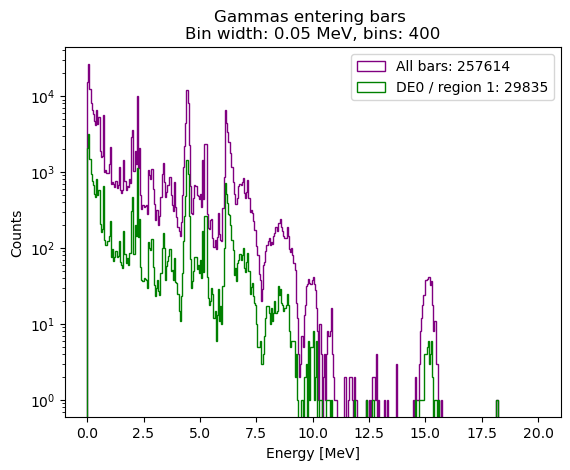

In [11]:
bin_width = 0.05 # MeV
min_energy = 0 # MeV
max_energy = 20   # MeV
bins = np.arange(min_energy, max_energy + bin_width, bin_width)

plt.hist(NOVO51_42_energies, bins=bins, label=f"All bars: {len(NOVO51_42_energies)}", color="purple", histtype="step")
plt.hist(first_bar_energies, bins=bins, label=f"DE0 / region 1: {len(first_bar_energies)}", color="green", histtype="step")

plt.xlabel("Energy [MeV]")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.title(f"Gammas entering bars \nBin width: {bin_width} MeV, bins: {len(bins) - 1}")

### Loading 80 data (detection)

In [22]:
NOVO51_80_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\Testing\Detector_efficiency\scintillator_interactions"

NOVO51_80_data = DetectionDataStorage(NOVO51_80_PATH, primaries_per_spawn=1.5e6, max_files=70, FLUKA_to_meas_coords=True)
NOVO51_80_data.load_data()
NOVO51_80_data.filter_hits(g_threshold=10)

NOVO51_80_data = NOVO51_80_data.gamma_hits

Reading 70 scintillator_interactions.txt-files
Total time used on data collection: 5.64 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 2.44 s
Total number of lines: 245121
Number of lines kept: 55755 (22.7%)
Number of lines rejected: 189366 (77.3%)

-----------HIT MERGING-----------
Merging complete. Time used: 0.98 s
Overlaps found: 7689
Total number of hit histories > 10/200 keV: 30426
Number of gamma hit histories > 10 keV: 17825
Number of neutron hit histories > 200 keV: 12564
Number of combo hit histories > 200 keV: 37


#### 9) Gammas detected and intrinsic efficiency

In [31]:
NOVO51_80_MREGs = NOVO51_80_data[:, 12]
NOVO51_80_energies = NOVO51_80_data[:, 7]
NOVO51_80_LLOUSEs = NOVO51_80_data[:, 4]
NOVO51_80_incident_energies = NOVO51_80_data[:, 8]

first_bar_mask_80 = NOVO51_80_MREGs==1
first_bar_hits = NOVO51_80_energies[first_bar_mask_80]
first_bar_LLOUSEs = NOVO51_80_LLOUSEs[first_bar_mask_80]
first_bar_incident_energy = NOVO51_80_incident_energies[first_bar_mask_80]

print(f"Number of gamma hits in all bars: {len(NOVO51_80_energies)}, direct: {round(100 * sum(NOVO51_80_LLOUSEs) / len(NOVO51_80_LLOUSEs), 2)}%")
#print(f"Intrinsic detection efficiency for all bars/energies: {round(100 * len(NOVO51_80_energies) / len(NOVO51_42_energies), 2)}%")
print("----------------")
print(f"Total number of gamma hits in DE0/region 1: {len(first_bar_hits)}, direct: {round(100 * sum(first_bar_LLOUSEs) / len(first_bar_hits), 2)}%")
#print(f"Intrinsic detection efficiency for DE0/region 1 for all energies: {round(100 * len(first_bar_hits) / len(first_bar_gammas_enter), 2)}%")

interval_width = 0.5
energy_check = 5

first_bar_incident_energy_5MeV_mask = (first_bar_incident_energy > energy_check - interval_width) & (first_bar_incident_energy < energy_check + interval_width)   # Incident photons must be around 5 MeV for comparison
first_bar_incident_energy_5MeV = first_bar_incident_energy[first_bar_incident_energy_5MeV_mask]

first_bar_energies_5MeV_mask = (first_bar_energies > 5 - interval_width) & (first_bar_energies < 5 + interval_width)    # Photons entering must around 5 MeV.
first_bar_energies_5MeV = first_bar_energies[first_bar_energies_5MeV_mask]

print("------------")
print(f"Number of gamma hits in DE0/region 1 incident photon energy {energy_check} MeV +- {interval_width} MeV: {len(first_bar_incident_energy_5MeV)}")
#print(f"Intrinsic detection efficiency for DE0/region for {energy_check} MeV +- {interval_width} MeV: {round(100 * len(first_bar_incident_energy_5MeV) / len(first_bar_energies_5MeV), 2)}%")

print("----------")
print(f"Time elapsed with 4e8 primaries, 2 nA: {round(4e8/1.25e10, 3)} s")
print(f"Number of detected hits in DE0 / region 1: {len(first_bar_hits)}")
print(f"Estimated count rate: {round(1e-3 * len(first_bar_hits)/(4e8/1.25e10), 2)} kcps")

Number of gamma hits in all bars: 17825, direct: 30.03%
----------------
Total number of gamma hits in DE0/region 1: 2057, direct: 28.44%
------------
Number of gamma hits in DE0/region 1 incident photon energy 5 MeV +- 0.5 MeV: 59
----------
Time elapsed with 4e8 primaries, 2 nA: 0.032 s
Number of detected hits in DE0 / region 1: 2057
Estimated count rate: 64.28 kcps


Text(0.5, 1.0, 'Intrinsic efficiency DE0/region 1 for 5 MeV: 0.0%\nBins = 100, energies +- 0.5 MeV')

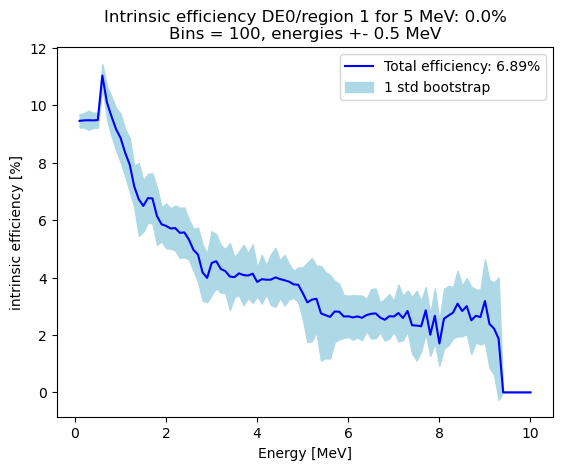

In [ ]:
interval_width = 0.5    # MeV
n_boostraps = 50
efficiencies = []
eff_errors = []
energy_bins = []

for energy in range(1, 101):
    energy_check = energy * 0.1   # MeV

    first_bar_incident_energy_XMeV_mask = (first_bar_incident_energy > energy_check - interval_width) & (first_bar_incident_energy < energy_check + interval_width)
    first_bar_incident_energy_XMeV = first_bar_incident_energy[first_bar_incident_energy_XMeV_mask]

    first_bar_energies_XMeV_mask = (first_bar_energies > energy_check - interval_width) & (first_bar_energies < energy_check + interval_width)
    first_bar_energies_XMeV = first_bar_energies[first_bar_energies_XMeV_mask]

    # Skip empty entries
    if len(first_bar_energies_XMeV) == 0:
        efficiencies.append(np.nan)
        eff_errors.append(np.nan)
        energy_bins.append(energy_check)

    # Estimate efficiency
    intrinsic_efficiency = 100 * len(first_bar_incident_energy_XMeV) / len(first_bar_energies_XMeV)
    efficiencies.append(intrinsic_efficiency)
    energy_bins.append(energy_check)

    # Boostrapping for uncertainty estimate
    bootstrap_vals = []

    for boot in range(n_boostraps):
        # Resample with replacement
        resample_first_bar_energies_XMeV = np.random.choice(first_bar_energies_XMeV, size=len(first_bar_energies_XMeV), replace=True)
        
        mask_resample_incident = np.isin(resample_first_bar_energies_XMeV, first_bar_incident_energy_XMeV)
        resample_incident_count = np.sum(mask_resample_incident)

        eff_boot = 100 * resample_incident_count / len(resample_first_bar_energies_XMeV)
        bootstrap_vals.append(eff_boot)

    eff_errors.append(np.std(bootstrap_vals))
        

#plt.scatter(energy_bins, efficiencies, color="blue", label=f"Total efficiency: {round(100 * len(first_bar_hits) / len(first_bar_gammas_enter), 2)}%")
plt.errorbar(
    energy_bins,
    efficiencies,
    yerr=eff_errors,
    fmt="o",
    color="blue",
    ecolor="lightblue",
    capsize=3,
    label=f"Total efficiency: {round(100 * len(first_bar_hits) / len(first_bar_gammas_enter), 2)}%"
)

#plt.plot(energy_bins, efficiencies, color="blue", label=f"Total efficiency: {round(100 * len(first_bar_hits) / len(first_bar_gammas_enter), 2)}%")
#plt.fill_between(energy_bins, np.array(efficiencies) + np.array(eff_errors), np.array(efficiencies) - np.array(eff_errors), color="lightblue", label="+-1 std, bootstrap")
plt.xlabel("Energy [MeV]")
plt.ylabel("intrinsic efficiency [%]")
plt.legend()
plt.title(f"Intrinsic efficiency DE0/region 1 for 5 MeV: {round(100 * len(first_bar_incident_energy_5MeV) / len(first_bar_energies_5MeV), 2)}%\nBins = 100, energies +- {interval_width} MeV")




#### XCOM data

[3.73021466 4.18659952 4.64082079 5.09288875 5.54281359 5.99060548
 6.43627453 6.8798308  7.32128431]


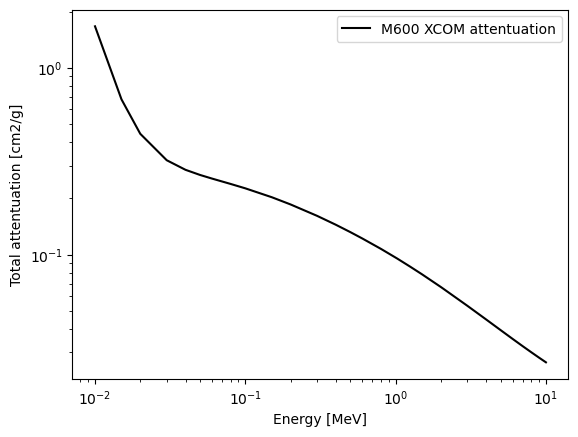

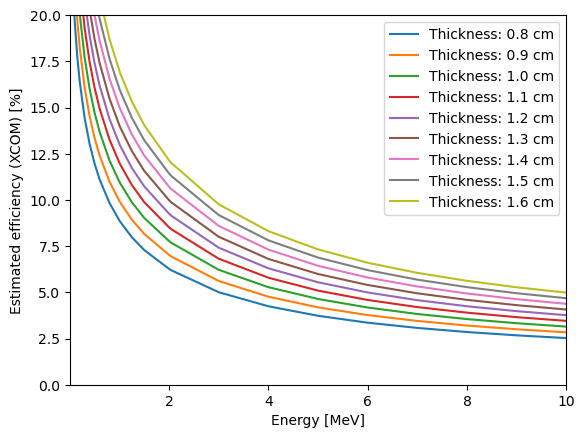

In [17]:
raw_XCOM_data = """
1.000E-02|1.670E+00|
1.500E-02|6.784E-01|
2.000E-02|4.436E-01|
3.000E-02|3.202E-01|
4.000E-02|2.845E-01|
5.000E-02|2.670E-01|
6.000E-02|2.554E-01|
8.000E-02|2.389E-01|
1.000E-01|2.264E-01|
1.500E-01|2.029E-01|
2.000E-01|1.856E-01|
3.000E-01|1.613E-01|
4.000E-01|1.445E-01|
5.000E-01|1.319E-01|
6.000E-01|1.220E-01|
8.000E-01|1.072E-01|
1.000E+00|9.635E-02|
1.022E+00|9.535E-02|
1.250E+00|8.615E-02|
1.500E+00|7.836E-02|
2.000E+00|6.703E-02|
2.044E+00|6.622E-02|
3.000E+00|5.319E-02|
4.000E+00|4.493E-02|
5.000E+00|3.937E-02|
6.000E+00|3.536E-02|
7.000E+00|3.233E-02|
8.000E+00|2.996E-02|
9.000E+00|2.805E-02|
1.000E+01|2.648E-02|"""

XCOM_energy_bin = []
XCOM_attenuations = []
entry_type = "Energy"
for entry in raw_XCOM_data.split("|"):

    if entry == "":
        continue
    entry = entry.replace("\n", "")

    entry = float(entry)

    if entry_type == "Energy":
        XCOM_energy_bin.append(entry)
        entry_type = "Attenuation"
    else:
        XCOM_attenuations.append(entry)
        entry_type = "Energy"
plt.plot(XCOM_energy_bin, XCOM_attenuations, color="black", label="M600 XCOM attentuation")
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [MeV]")
plt.ylabel("Total attentuation [cm2/g]")
plt.legend()

thicknesses = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6] # cm

def theoretical_efficiency(XCOM_attenuation, thickness):
    density = 1.207 # g/cm3

    return  1 - math.exp(-XCOM_attenuation * density * thickness)

estimated_efficiencies = []
for XCOM_energy, XCOM_attenuation in zip(XCOM_energy_bin, XCOM_attenuations):
    est_eff = [theoretical_efficiency(XCOM_attenuation, thickness) for thickness in thicknesses]

    estimated_efficiencies.append(est_eff)

estimated_efficiencies = np.array(estimated_efficiencies)

estimated_efficiencies_per_thickness = np.transpose(estimated_efficiencies)

plt.figure()

for index, thickness in enumerate(thicknesses):
    plt.plot(XCOM_energy_bin, 100 * estimated_efficiencies_per_thickness[index], label=f"Thickness: {thickness} cm")
#plt.xscale("log")
#plt.yscale("log")

plt.xlabel("Energy [MeV]")
plt.ylabel("Estimated efficiency (XCOM) [%]")
plt.xlim([0.01, 10])
plt.ylim([0, 20])
plt.legend()

index5MeV = 24
efficiencies5MeV = 100 * estimated_efficiencies[index5MeV]
print(efficiencies5MeV)


#### 10) Estimating counts per scintillator for the Na-22 source

In [18]:
Na22_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\Testing\Na22_source\scintillator_interactions"

Na22_detect = DetectionDataStorage(Na22_PATH, primaries_per_spawn=1.2e6, max_files=70)
Na22_detect.load_data()

Na22_detect.filter_hits(time_structure="continuous", beam_current=1.45e-4)    # Need another time structure (constant according to 906 kBq -> 1.45e-4 "nA": Page 70 in small green notebook)

Reading 70 scintillator_interactions.txt-files
Total time used on data collection: 13.04 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 13.54 s
Total number of lines: 1094698
Number of lines kept: 533481 (48.7%)
Number of lines rejected: 561217 (51.3%)

-----------HIT MERGING-----------
Merging complete. Time used: 9.0 s
Overlaps found: 47343
Total number of hit histories > 10/200 keV: 459868
Number of gamma hit histories > 10 keV: 459868
Number of neutron hit histories > 200 keV: 0
Number of combo hit histories > 200 keV: 0


#### Loading 42 data for Na-22 source

In [19]:
# Loading data

Na22_42_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\PTB model\Simulations\Testing\Na22_source\gammas_enter_scints"
prim_per_spawn = 1.2e6  # x 70 spawns =  8.4e7 primaries in total x 4 detectors = effectively 3.36e8 primaries 
Na22_42_data = []

Na22_42_folder = os.listdir(Na22_42_PATH)
n_files = len(os.listdir(Na22_42_PATH))

n = 0   # Line counter
m = 0   # File counter

time_stamp = time.time()

print(f"Reading {n_files} gammas_enter_scints.txt-files")

for filename in Na22_42_folder:
    
    m += 1

    # Skip any other files
    if "gammas_enter_scints.txt" not in filename:
        break

    data_entry = collect_txt_data_42(Na22_42_PATH + "\\" + filename, primaries_per_spawn=prim_per_spawn , spawn_number=m, FLUKA_to_meas_coords=True) # Shape [eg. (3000, 1), ..., (3000, 1)]
    Na22_42_data.append(data_entry)

Na22_42_data = np.transpose(np.concatenate(Na22_42_data, axis=1))

Reading 70 gammas_enter_scints.txt-files


#### 11) Specter for Na-22 source hits

Text(0.5, 1.0, 'Incident photon spectra for Na22 (DE0 / region 1) \n Energy deposit cut: >= 100 keV')

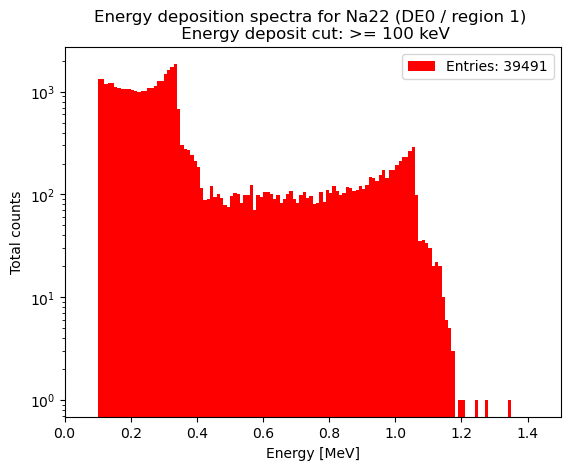

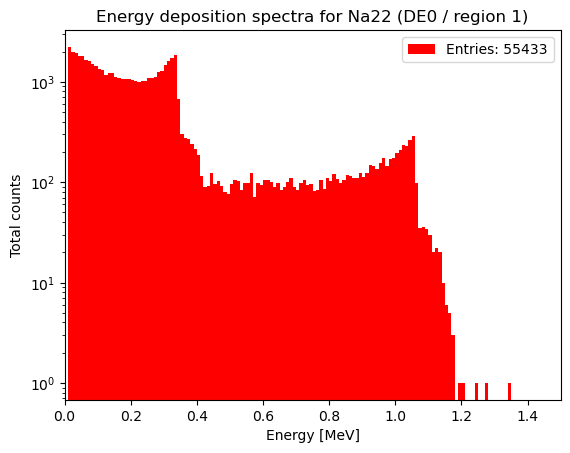

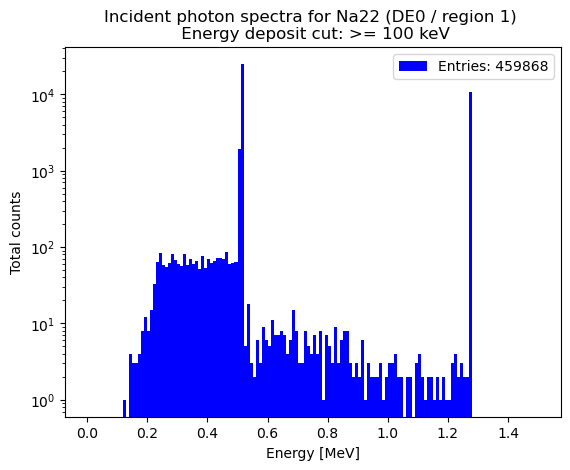

In [20]:
Na22_gamma_hits = Na22_detect.gamma_hits

Na22_energy_deposits = Na22_gamma_hits[:, 7]
Na22_incident_energies = Na22_gamma_hits[:, 8]
Na22_regions = Na22_gamma_hits[:, 12]

Na22_region_mask = Na22_regions==1

Na22_energy_deposits_reg1 = Na22_energy_deposits[Na22_region_mask]
Na22_incident_energies_reg1 = Na22_incident_energies[Na22_region_mask]

Na22_energy_mask = Na22_energy_deposits_reg1>=0.100    # MeV

Na22_energy_deposits_reg1_ecut = Na22_energy_deposits_reg1[Na22_energy_mask]
Na22_incident_energies_reg1_ecut = Na22_incident_energies_reg1[Na22_energy_mask]

bin_width = 0.01 # MeV
max_energy = 1.5 # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)

plt.figure()
plt.hist(Na22_energy_deposits_reg1_ecut, bins=bins, color="red", label=f"Entries: {len(Na22_energy_deposits_reg1_ecut)}")
plt.yscale("log")
plt.xlim([0, 1.5])
plt.xlabel("Energy [MeV]")
plt.ylabel("Total counts")
plt.legend()
plt.title("Energy deposition spectra for Na22 (DE0 / region 1) \n Energy deposit cut: >= 100 keV")

plt.figure()
plt.hist(Na22_energy_deposits_reg1, bins=bins, color="red", label=f"Entries: {len(Na22_energy_deposits_reg1)}")
plt.yscale("log")
plt.xlim([0, 1.5])
plt.xlabel("Energy [MeV]")
plt.ylabel("Total counts")
plt.legend()
plt.title("Energy deposition spectra for Na22 (DE0 / region 1)")


plt.figure()
plt.hist(Na22_incident_energies_reg1_ecut, bins=bins, color="blue", label=f"Entries: {len(Na22_incident_energies)}")
#plt.xlim([0, 1.5])
plt.yscale("log")
plt.xlabel("Energy [MeV]")
plt.ylabel("Total counts")
plt.legend()
plt.title("Incident photon spectra for Na22 (DE0 / region 1) \n Energy deposit cut: >= 100 keV")

Total number of gammas entering any bar: 4697095
Intrinsic efficiency (all energies, all bars): 9.79%
-------------
Numbers of gammas entering DE0 bar: 586413
Number of photons detected in DE0 bar: 55433
Ratio of photons entering DE0 / region 1 per photon emitted: 6.23e-4
Intrinsic efficiency (all energies, DE0 / region 1): 9.45%


Text(0.5, 1.0, 'Photons entering DE0 / region 1')

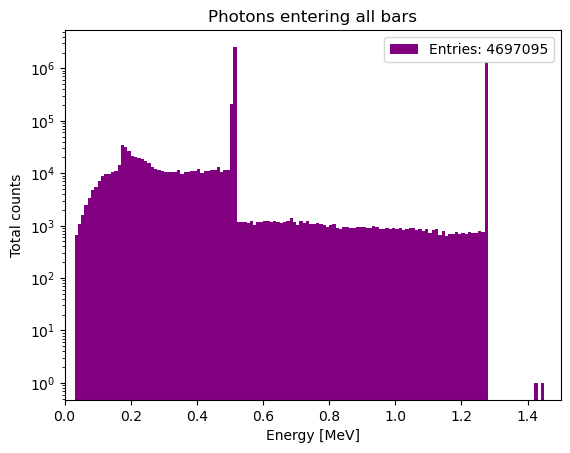

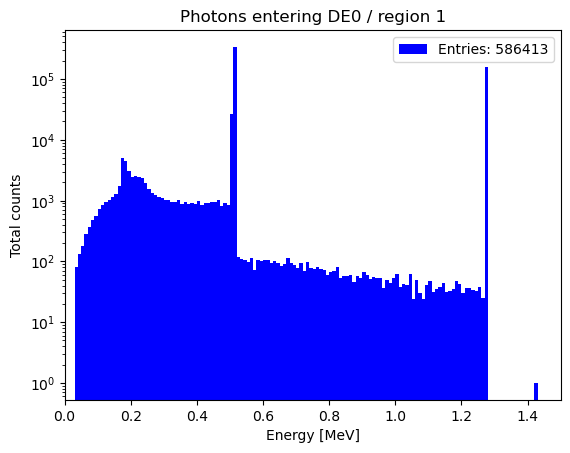

In [21]:
Na22_42_NCASEs = Na22_42_data[:, 0]
Na22_42_LLOUSEs = Na22_42_data[:, 1]
Na22_42_MREGs = Na22_42_data[:, 2]
Na22_42_energies = Na22_42_data[:, 3]
Na22_42_ZSCO = Na22_42_data[:, 4]

Na22_total_gammas_enter_scints = len(Na22_42_MREGs)
Na22_first_bar_mask = Na22_42_MREGs==1 # Region 1 / Detector element 0
Na22_first_bar_gammas_enter = Na22_42_MREGs[Na22_first_bar_mask]
Na22_first_bar_energies = Na22_42_energies[Na22_first_bar_mask] # A tool for later
Na22_total_photons_emitted = 1.2e6 * 70 * 4 * 2.8

# NB! NB!: We have four (4) times as much detection data as production data due to the four detector copies!!! Vales are therefore multiplied by 0.25/4 where needed!

print(f"Total number of gammas entering any bar: {Na22_total_gammas_enter_scints}")
print(f"Intrinsic efficiency (all energies, all bars): {round(100 * len(Na22_energy_deposits) / Na22_total_gammas_enter_scints, 2)}%")
print("-------------")
print(f"Numbers of gammas entering DE0 bar: {len(Na22_first_bar_gammas_enter)}")
print(f"Number of photons detected in DE0 bar: {len(Na22_energy_deposits_reg1)}")
print(f"Ratio of photons entering DE0 / region 1 per photon emitted: {round(1e4 * len(Na22_first_bar_gammas_enter) / Na22_total_photons_emitted, 2)}e-4")
print(f"Intrinsic efficiency (all energies, DE0 / region 1): {round(100 * len(Na22_energy_deposits_reg1) / len(Na22_first_bar_gammas_enter), 2)}%")

bin_width = 0.01 # MeV
max_energy = 1.5 # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)

plt.figure()
plt.hist(Na22_42_energies, bins=bins, color="purple", label=f"Entries: {len(Na22_42_energies)}")
plt.yscale("log")
plt.xlim([0, 1.5])
plt.xlabel("Energy [MeV]")
plt.ylabel("Total counts")
plt.legend()
plt.title("Photons entering all bars")

plt.figure()
plt.hist(Na22_first_bar_energies, bins=bins, color="blue", label=f"Entries: {len(Na22_first_bar_energies)}")
plt.yscale("log")
plt.xlim([0, 1.5])
plt.xlabel("Energy [MeV]")
plt.ylabel("Total counts")
plt.legend()
plt.title("Photons entering DE0 / region 1")
